# AAX: Seminar 5

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import csv
import io
import random
import numpy as np
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import seaborn as sns
import torch.nn as nn

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Part I: ML model definition

In [ ]:
# We define a Logistic Classifier as a model
class LogisticClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

# Part II: Preparation of the FL setting

In [ ]:
# We define a dictionary for saving the datasets (key = client_id, value = (features,labels))
datasets = {}

# We save our datasets
for i in range(10):
  features = pd.read_csv('/content/drive/Shareddrives/MLNETWORKS/SEMIS/S5/dataset_Seminar5/client_datasets/client_' + str(i+1) + '_features.csv', sep=',', header=None)
  labels = pd.read_csv('/content/drive/Shareddrives/MLNETWORKS/SEMIS/S5/dataset_Seminar5/client_datasets/client_' + str(i+1) + '_labels.csv', sep=',', header=None)
  datasets[i+1] = (features, labels)

In [ ]:
# 1. Generate a global model
input_dim = datasets[1][0].shape[1]  # Number of features
num_classes = 12
global_model = LogisticClassifier(input_dim, num_classes)

In [ ]:
# WE DEFINE SOME AUXILIARY FUNCTIONS TO USE DURNIG THE FEDERATED LEARNING

# A function to get the weights of the model
def get_model_weights(model):
  state_dict = model.state_dict()
  weights_copy = {}
  for k,v in state_dict.items():
    weights_copy[k] = v.clone() # We clone to avoid referencing
  return weights_copy

# A function to set the model weights
def set_model_weights(model, weights):
  model.load_state_dict(weights)

# A function to train the local model
def local_train(local_model, features, labels, lr = 0.001, epochs = 5):

  # We define the local model
  model = LogisticClassifier(input_dim, num_classes)
  set_model_weights(model, get_model_weights(global_model))
  model.train()

  optimizer = torch.optim.SGD(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()

  # Converting features and labels into tensors of PyTorch
  X = torch.tensor(features.values, dtype=torch.float32)
  y = torch.tensor(labels.values.flatten(), dtype=torch.long)

  # We adjust the labels from indices 1-12 to 0-11
  y = y - 1

  # We train the model
  for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()

  # Comuting the weights and the size
  weights = get_model_weights(model)
  size = len(y)

  # And we return them
  return weights, size

# A function to perform federated averaging
def fed_avg(models_weights, data_sizes):

    total_size = sum(data_sizes)
    avg_weights = {}

    # Iterate through each layer
    for key in models_weights[0].keys():

        # Initialize the sum of weights for this layer
        layer_sum = 0

        # For each client, we compute the weighted contribution
        for w, n in zip(models_weights, data_sizes):

            # Proportion of data w.r.t the total
            alpha = n / total_size

            # We compute the weighted weught
            client_weight = w[key]
            weighted_weight = client_weight * alpha

            # Accumulating in the total sum of the layer
            layer_sum += weighted_weight

        # We save its sum in the dictionary
        avg_weights[key] = layer_sum

    return avg_weights

In [ ]:
# FEDERATED LEARNING

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

epochs = 10
subset_size = 5

for i in range(epochs):

  # 2. Client selection
  selected_clients = random.sample(list(datasets.keys()), subset_size)

  local_weights = []
  local_sizes = []

  # 3. Local training
  for client_id in selected_clients:
    features, labels = datasets[client_id]
    weights, size = local_train(global_model, features, labels)

    # 4. Retrieving the individual models
    local_weights.append(weights)
    local_sizes.append(size)

  # 5. Model aggregation
  new_global_weights = fed_avg(local_weights, local_sizes)
  set_model_weights(global_model, new_global_weights)


# Part III: Collaborative training of the model

In [ ]:
# Saving the test features and labels
test_features = pd.read_csv('/content/drive/Shareddrives/MLNETWORKS/SEMIS/S5/dataset_Seminar5/test_features.csv', header=None)
test_labels = pd.read_csv('/content/drive/Shareddrives/MLNETWORKS/SEMIS/S5/dataset_Seminar5/test_labels.csv', header=None)

# Converting features and labels into tensors of PyTorch
X_test = torch.tensor(test_features.values, dtype=torch.float32)
y_test = torch.tensor(test_labels.values.flatten(), dtype=torch.long)

# Adjusting the labels from indices 1-12 to 0-11
y_test = y_test - 1

In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# We define the hyperparameters
epochs_FL = 10000
epochs_local = 5
lr = 0.01
subset_size = len(datasets)

# We restart the model to try our hyperparameters
global_model = LogisticClassifier(input_dim, num_classes)

# We define an array to plot the accuracies
accuracies = []

# We train the model using this new hyperparameters
for epoch in range(epochs_FL):
    selected_clients = random.sample(list(datasets.keys()), subset_size)
    local_weights = []
    local_sizes = []

    for client_id in selected_clients:
        features, labels = datasets[client_id]
        weights, size = local_train(global_model, features, labels, lr, epochs_local)
        local_weights.append(weights)
        local_sizes.append(size)

    new_global_weights = fed_avg(local_weights, local_sizes)
    set_model_weights(global_model, new_global_weights)

    # Evaluating after each round
    global_model.eval()
    with torch.no_grad():
        outputs = global_model(X_test)
        predicted = torch.argmax(outputs, dim=1)
        accuracy = (predicted == y_test).float().mean()
        accuracies.append(accuracy)
    if epoch % 100 == 0:
      print("Epoch:", epoch+1, "-- Test Accuracy:", round(accuracy.item(),6))

Epoch: 1 -- Test Accuracy: 0.094
Epoch: 101 -- Test Accuracy: 0.196
Epoch: 201 -- Test Accuracy: 0.166
Epoch: 301 -- Test Accuracy: 0.244
Epoch: 401 -- Test Accuracy: 0.228
Epoch: 501 -- Test Accuracy: 0.28
Epoch: 601 -- Test Accuracy: 0.28
Epoch: 701 -- Test Accuracy: 0.31
Epoch: 801 -- Test Accuracy: 0.336
Epoch: 901 -- Test Accuracy: 0.304
Epoch: 1001 -- Test Accuracy: 0.34
Epoch: 1101 -- Test Accuracy: 0.308
Epoch: 1201 -- Test Accuracy: 0.308
Epoch: 1301 -- Test Accuracy: 0.324
Epoch: 1401 -- Test Accuracy: 0.342
Epoch: 1501 -- Test Accuracy: 0.394
Epoch: 1601 -- Test Accuracy: 0.36
Epoch: 1701 -- Test Accuracy: 0.344
Epoch: 1801 -- Test Accuracy: 0.392
Epoch: 1901 -- Test Accuracy: 0.344
Epoch: 2001 -- Test Accuracy: 0.326
Epoch: 2101 -- Test Accuracy: 0.372
Epoch: 2201 -- Test Accuracy: 0.418
Epoch: 2301 -- Test Accuracy: 0.354
Epoch: 2401 -- Test Accuracy: 0.308
Epoch: 2501 -- Test Accuracy: 0.402
Epoch: 2601 -- Test Accuracy: 0.388
Epoch: 2701 -- Test Accuracy: 0.374
Epoch: 28

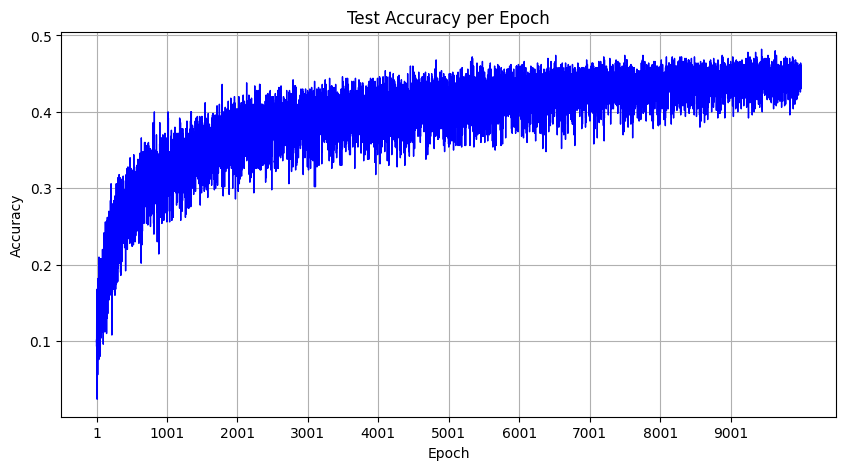

In [ ]:
# We plot the accuracies through epochs

plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs_FL+1), accuracies, linestyle='-', color='blue', linewidth=1)
plt.title('Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xticks(range(1, epochs_FL+1, max(1, epochs_FL//10)))
plt.show()

The accuracy starts very low (around 5%) and then improves very fast in the first 1000-1500 iterations. Then, the growth gets stabilized with little oscilations, reaching a maximum close to 45%.

These oscilations are due to the random selection of clients and the variability of the training that this cause.

The model learns but we can see a ceiling in the learning. Although 45% is a low value, since there are 12 classes, it is much more accurate than random (which would be around 8.3%).

These limited results could be causes by not representative or differentiable data between classes or by a low quality of the regression model.

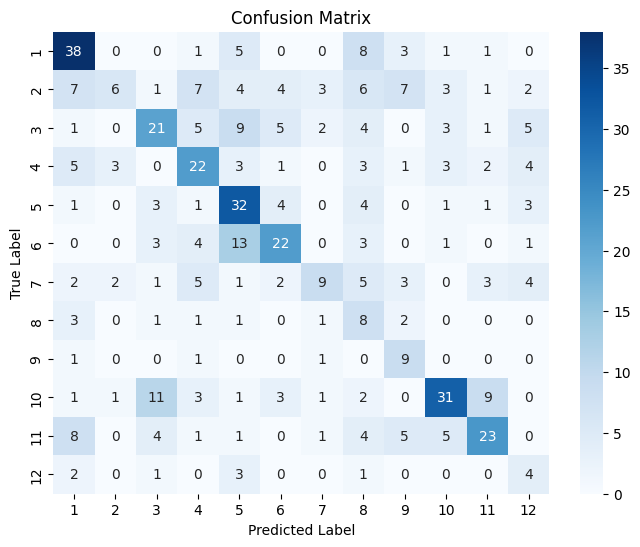

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

# Final predictions
global_model.eval()
with torch.no_grad():
    outputs = global_model(X_test)
    predicted = torch.argmax(outputs, dim=1)

# Confusion matric
cm = confusion_matrix(y_test.numpy(), predicted.numpy())

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i+1) for i in range(12)],
            yticklabels=[str(i+1) for i in range(12)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Reporte detallado por clase
report = classification_report(y_test.numpy(), predicted.numpy(), labels=range(12), digits=4)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0     0.5507    0.6667    0.6032        57
           1     0.5000    0.1176    0.1905        51
           2     0.4565    0.3750    0.4118        56
           3     0.4314    0.4681    0.4490        47
           4     0.4384    0.6400    0.5203        50
           5     0.5366    0.4681    0.5000        47
           6     0.5000    0.2432    0.3273        37
           7     0.1667    0.4706    0.2462        17
           8     0.3000    0.7500    0.4286        12
           9     0.6458    0.4921    0.5586        63
          10     0.5610    0.4423    0.4946        52
          11     0.1739    0.3636    0.2353        11

    accuracy                         0.4500       500
   macro avg     0.4384    0.4581    0.4138       500
weighted avg     0.4931    0.4500    0.4454       500



In the classification report, class 0 means label 1 in the data, class1 means label 2 and so on.

The general accuracy is 45.0%, the average recall is 45.8% and the average precision is 49.31%. Highest recalls are in label 1 (0.6667) and label 9 (0.75). However, we have to take into account that label 9 has only 12 samples, so these performance could not be representative. Lowest recalls are in labels 2 (0.1176) and 7 (0.2432).

Looking at these results, we can conclude that the model is not consisten between classes, since with some classes it has good performance and with others it works very badly.

The low recall values in some classes suggest that the models is not able to detect enough examples or features to distinguish between classes. This could be caused by a dataset not representative enough or by a model not able to capture the variability of the data.

Finally, we could say that in general classes with low support (for example labels 8, 9, and 12) tend to be more difficult to predict. This seems logical since in classes with less data it is more difficult to capture patterns that allow the model to ditinguish this class.
